<a href="https://colab.research.google.com/github/ulumbagas/CNN_code/blob/main/Handwritten%20Japanese%20Hiragana/Handwritten_Japanese_Hiragana_Characters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Preparation

## Data Collection

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("farukece/handwritten-japanese-hiragana-characters")

print("Path to dataset files:", path)

100%|██████████| 31.7M/31.7M [00:00<00:00, 58.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/farukece/handwritten-japanese-hiragana-characters/versions/1


In [2]:
"""
This script is used to explore and summarize a dataset of Hiragana character images.
It scans through the dataset folder, counts the number of images in each class folder,
and organizes the results into a pandas DataFrame for easier analysis.
"""

import pandas as pd
import numpy as np
from pathlib import Path

# Define the dataset path (make sure 'path' variable is set correctly before running)
path = Path(path)

# Define the directory that contains all Hiragana character subfolders
hiragana_dir=path/'hiragana'

# List all items (subdirectories/files) inside the 'hiragana' folder
img_dir=list(hiragana_dir.iterdir())


# Print the total number of classes (subfolders) inside 'hiragana'
print(f'number of class: {len(list(hiragana_dir.iterdir()))}')


hiragana = []
hiragana_files = []
# Ensure hiragana_dir is a Path object
hiragana_dir = Path(hiragana_dir)

for folder_path in hiragana_dir.iterdir():
    if folder_path.is_dir():   # only process directories (ignore stray files if any)
        num_files = len(list(folder_path.iterdir()))
        hiragana.append(folder_path.name)
        hiragana_files.append(num_files)

# Create a pandas DataFrame to summarize the dataset
df = pd.DataFrame({'class': hiragana,'Image Dir':img_dir ,'number of files': hiragana_files})


number of class: 46


## Plot image

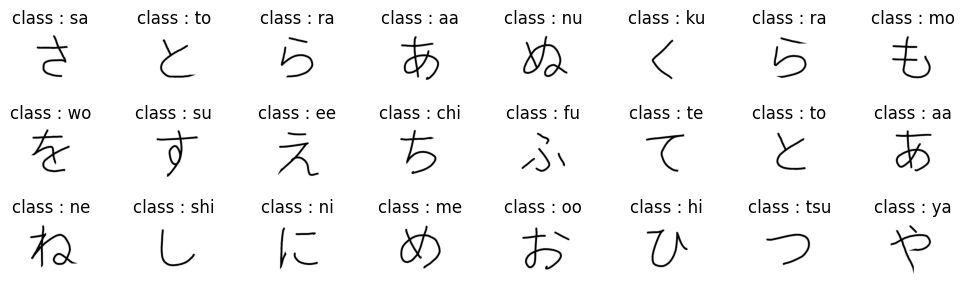

In [3]:
"""
This script is used to visualize random images from the Hiragana dataset.
It selects random class folders (labels), picks random images inside them,
and plots them in a grid layout using matplotlib.

"""
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchsummary import summary


# Get all class folders from dataset directory (each folder = one class)
labels = list(hiragana_dir.iterdir())
kolom=8
baris=3

# Create a matplotlib figure with specified grid layout
fig, axes = plt.subplots(baris, kolom, figsize=(10, 3))  # 1 baris, 2 kolom
axes = axes.flatten()

# Loop through each subplot (axis) and display a random image
for _, ax in enumerate(axes):

    # Pick a random class folder
    label = random.choice(labels)

    # Pick a random image from that class folder
    images = list(label.iterdir())
    img_path = random.choice(images)

    # Read image using matplotlib
    gambar_hiragana = mpimg.imread(img_path)

    # Show the image on the subplot
    ax.imshow(gambar_hiragana)
    ax.axis("off")
    ax.set_title(f'class : {label.name}', fontsize=12)
plt.tight_layout()
plt.show()

## cek size

In [4]:
uniq_size=set()
for folder_path in hiragana_dir.iterdir():
    for file_path in folder_path.iterdir():
        uniq_size.add(Image.open(file_path).size)
print(uniq_size)
print('all image has same size')

{(500, 400)}
all image has same size


## Data transform

chi


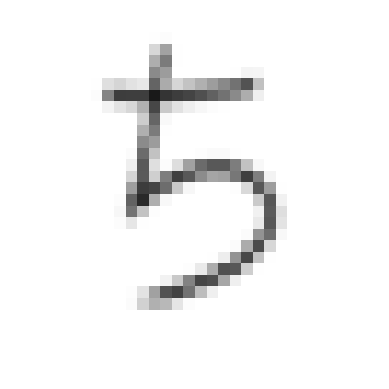

In [5]:
labels = list(hiragana_dir.iterdir())
label = random.choice(labels)
images = list(label.iterdir())
img_path = random.choice(images)

img = Image.open(img_path)
crop = torchvision.transforms.Resize(size=(32, 32))
print(label.name)
plt.axis("off")
plt.imshow(crop(img));

## Data Augmetation


In [6]:
"""
This script defines data transformations (preprocessing and augmentation)
for training and testing a CNN model on grayscale images (Hiragana dataset).

- Train transform:
  Includes data augmentation (random rotation, affine transform, jitter, erasing)
  to improve model generalization.

- Test transform:
  Minimal processing (no augmentation), only resizing and normalization,
  to ensure evaluation consistency.
"""

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import v2

# Transform untuk train (ada augmentasi)
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.RandomRotation(5),
    transforms.RandomAffine(degrees=10,translate=(0.1, 0.1),shear=5),
    v2.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# Transform untuk test (tanpa augmentasi, cuma resize & tensor)
test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])



## Split data

In [7]:
"""
This script is used to split a dataset of images into training and testing sets.
It uses the `splitfolders` library, which automatically divides images based
on folder structure (class-wise).

Steps performed:
1. Try importing `splitfolders`. If not installed, install it first.
2. Use `splitfolders.ratio` to split the dataset into train and test folders.

Arguments used in split:
- input   : Path to the original dataset (each class is a subfolder).
- output  : Directory where the split dataset will be saved.
- seed    : Random seed for reproducibility.
- ratio   : Tuple specifying train/test ratio (e.g., (0.85, 0.15) = 85% train, 15% test).
"""

try:
    import splitfolders
except ImportError:
    !pip install split-folders
    import splitfolders


splitfolders.ratio(
    input=hiragana_dir,
    output='imgs',
    seed=42,
    ratio=(0.9, 0.1)  # 90% train, 10% test
)

Copying files: 4600 files [00:00, 4604.72 files/s]


In [8]:
"""
This script loads image datasets (train and validation/test)
using torchvision's `ImageFolder` class.

- Dataset structure must follow:
    root/train/class_x/xxx.png
    root/train/class_y/yyy.png
    root/val/class_x/xxx.png
    root/val/class_y/yyy.png

- Each subfolder name = class label.
- Transforms (defined earlier) are applied automatically when images are loaded.
"""


img_path=Path('/content/imgs')
train_dir=img_path/'train'
val_dir=img_path/'val'

# Use ImageFolder to create dataset(s)
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir, # target folder of images
                                  transform=train_transform, # transforms to perform on data (images)
                                  target_transform=None)
test_data = datasets.ImageFolder(root=val_dir,
                                 transform=test_transform,
                                 target_transform=None)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 4140
    Root location: /content/imgs/train
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-5.0, 5.0], interpolation=nearest, expand=False, fill=0)
               RandomAffine(degrees=[-10.0, 10.0], translate=(0.1, 0.1), shear=[-5.0, 5.0])
               RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=[0.0], inplace=False)
               ToTensor()
               Normalize(mean=[0.5], std=[0.5])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 460
    Root location: /content/imgs/val
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.

In [9]:
bs=32
# Turn train and test Datasets into DataLoaders
train_loader = DataLoader(dataset=train_data,
                              batch_size=bs, # how many samples per batch?
                              num_workers=0, # how many subprocesses to use for data loading? (higher = more)
                              shuffle=True) # shuffle the data?

test_loader = DataLoader(dataset=test_data,
                             batch_size=bs,
                             num_workers=0,
                             shuffle=False) # don't usually need to shuffle testing data



## Model

In [10]:
from torch import nn
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


class MyCNN(nn.Module):
    def __init__(self, num_classes,do):
        super(MyCNN, self).__init__()

        # Feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(16, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Hitung ukuran flatten otomatis
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, 32, 32)  # batch=1, channel=1, H=32, W=32
            dummy_output = self.features(dummy_input)
            flatten_size = dummy_output.numel() // dummy_output.size(0)  # total fitur per sample
            print(f"[DEBUG] Flatten size: {flatten_size}")

        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_size, 128),
            nn.ReLU(),
            #nn.Dropout(do),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



num_classes = len(train_data.classes)
model = MyCNN(num_classes,do=0.25).to(device)

# Opsional: lihat struktur model
print(model)

[DEBUG] Flatten size: 4096
MyCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=46, bias=True)
  )
)


In [11]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

## Training

In [12]:
from tqdm.auto import tqdm
import torch

def train_step(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for features, targets in tqdm(dataloader, desc="Training", leave=False):
        features, targets = features.to(device), targets.to(device)

        # Forward
        outputs = model(features)
        loss = criterion(outputs, targets)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss & accuracy
        total_loss += loss.item() * features.size(0)
        preds = torch.argmax(outputs, dim=1)
        total_correct += (preds == targets).sum().item()
        total_samples += features.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc


def test_step(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for features, targets in tqdm(dataloader, desc="Validating", leave=False):
            features, targets = features.to(device), targets.to(device)

            outputs = model(features)
            loss = criterion(outputs, targets)

            total_loss += loss.item() * features.size(0)
            preds = torch.argmax(outputs, dim=1)
            total_correct += (preds == targets).sum().item()
            total_samples += features.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5):
    for epoch in range(1, epochs + 1):
        print(f"\nEpoch [{epoch}/{epochs}]")

        train_loss, train_acc = train_step(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test_step(model, test_loader, criterion, device)

        print(f"Train Loss: {train_loss:.7f} | Train Acc: {train_acc:.4f}")
        print(f"Test   Loss: {val_loss:.7f} | Test   Acc: {val_acc:.4f}")
        print("=" * 60)

In [14]:
train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=10)


Epoch [1/10]


Training:   0%|          | 0/130 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 3.8298763 | Train Acc: 0.0232
Test   Loss: 3.8061120 | Test   Acc: 0.0478

Epoch [2/10]


Training:   0%|          | 0/130 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 1.7574046 | Train Acc: 0.5674
Test   Loss: 0.4245124 | Test   Acc: 0.9587

Epoch [10/10]


Training:   0%|          | 0/130 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 1.6156412 | Train Acc: 0.5995
Test   Loss: 0.3263347 | Test   Acc: 0.9761


In [15]:
def predict_image_from_path(model, img_path, device, class_names):
    model.eval()

    # 1️⃣ Open Image
    img = Image.open(img_path)
    img_tensor = test_transform(img).unsqueeze(0).to(device)

    # 2️⃣ Prediction
    with torch.no_grad():
        output = model(img_tensor)
        pred_class = torch.argmax(output, dim=1).item()

    # 3️⃣ Show
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_class]}")
    plt.axis("off")
    plt.show()

Target : ru 


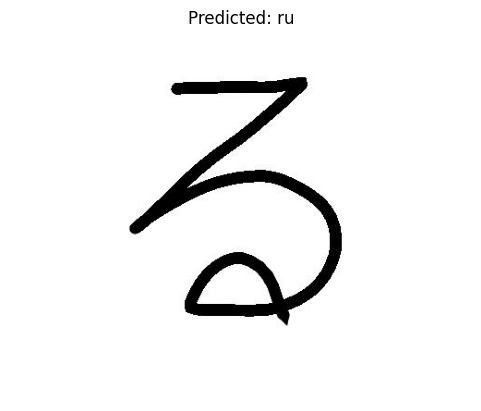

In [16]:
folder_hiragana=Path('/content/imgs/val')
labels_hiragana = list(folder_hiragana.iterdir())
target= random.choice(labels_hiragana)
images_guest=list(target.iterdir())
img_guest=random.choice(images_guest)
print(f'Target : {target.name} ')
predict_image_from_path(model,img_guest, device, train_data.classes)

